# Netflix Dataset Analysis

This notebook that loads `Netflix Dataset.csv`, performs minimal preprocessing, and produces basic analyses: Movies vs TV Shows over time, genre trends, country contributions, and a short summary with recommendations.

Instructions:
- The notebook uses pandas, matplotlib, and seaborn. 

In [ ]:
# Imports and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
%matplotlib inline

In [ ]:
# Load CSV and prepare df2
path = 'Netflix Dataset.csv'
try:
    df = pd.read_csv(path)
except FileNotFoundError:
    raise FileNotFoundError(f'Could not find {path} in the notebook folder.')

df2 = df.copy()
# clean headers
df2.columns = [str(c).strip() for c in df2.columns]
# drop stray 'nan'/'None' columns
_drop_candidates = [c for c in df2.columns if str(c).strip().lower() in ('nan', 'none', '')]
if _drop_candidates:
    df2 = df2.drop(columns=_drop_candidates)
    print('Dropped stray columns:', _drop_candidates)
# ensure show_type exists
if 'show_type' not in df2.columns:
    df2['show_type'] = df2.get('type', pd.NA)

print('Loaded df with shape:', df.shape, ' — working df2 shape:', df2.shape)
df.head(3)

Loaded df with shape: (7789, 11)  — working df2 shape: (7789, 12)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


In [ ]:
# Trend: Movies vs TV by year
if 'year' not in df2.columns:
    print("Run the parsing cell to create df2['year']")
else:
    df2['year'] = pd.to_numeric(df2['year'], errors='coerce').astype('Int64')
    # canonicalize type
    if 'show_type' in df2.columns:
        src = df2['show_type'].fillna('').astype(str)
    else:
        tcol = next((c for c in df2.columns if c.lower()=='type' or 'type' in c.lower()), None)
        src = df2[tcol].fillna('').astype(str) if tcol else None
    if src is None:
        print("No type info to canonicalize")
    else:
        low = src.str.lower()
        is_movie = low.str.contains('movie', na=False)
        is_tv = (low.str.contains('tv', na=False) | low.str.contains('show', na=False) | low.str.contains('series', na=False))
        import numpy as np
        canon = np.where(is_movie, 'Movie', np.where(is_tv, 'TV Show', pd.NA))
        df2['_show_type_canon'] = pd.Series(canon, index=df2.index)
        trend = (
            df2.dropna(subset=['year'])
               .dropna(subset=['_show_type_canon'])
               .groupby(['year', '_show_type_canon'])
               .size()
               .reset_index(name='count')
        )
        trend = trend.sort_values('year').rename(columns={'_show_type_canon': 'show_type'})
        display(trend.head(12))
    # top genres by year
    if 'primary_genre' in df2.columns:
        g = (df2.dropna(subset=['year', 'primary_genre'])
               .assign(primary_genre=df2['primary_genre'].astype(str).str.strip())
               .groupby(['year', 'primary_genre'])
               .size()
               .reset_index(name='count')
        )
        g_top = g.sort_values(['year', 'count'], ascending=[True, False]).groupby('year').head(3)
        print("\nTop genres per year (top 3):")
        display(g_top.reset_index(drop=True))

In [ ]:
# Basic stats for numerical columns
df.describe(include='all')

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s684,Movie,Backfire,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


## Preprocessing
- Parse date column, create `year` column.
- Normalize 'type' (Movie/TV Show).
- For genres, spliting the `listed_in` or `genre` column if present and create a simple 'primary_genre' by taking the first listed genre.

In [19]:
year_col = df['Release_Date']

In [52]:
# Make a copy to work with
df2 = df.copy()

# Normalize column names by stripping surrounding whitespace (keep original case)
df2.columns = [c.strip() for c in df2.columns]

# Prepare lowercase column list for robust detection
lower_cols = [c.lower() for c in df2.columns]

# Identify possible year/date columns (common patterns: 'year', 'date', 'release', 'date_added')
candidates = [c for c in df2.columns if 'date' in c.lower()]
# show candidates to confirm detection
print('candidate columns found:', candidates)
candidates

candidate columns found: ['Release_Date']


['Release_Date']

In [53]:
# Simple parsing cell: detect column, parse dates, create year
col = year_col if 'year_col' in globals() and isinstance(year_col, str) and year_col in df2.columns else 'Release_Date'
if col not in df2.columns:
    print("No date column found. Run: print(list(df2.columns))")
else:
    df2['release_date_parsed'] = pd.to_datetime(df2[col], errors='coerce')
    df2['year'] = df2['release_date_parsed'].dt.year.astype('Int64')
    print(sorted([int(y) for y in df2['year'].dropna().unique()])[:20])
    display(df2[[col, 'release_date_parsed', 'year']].head(6))

[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]


,Release_Date,release_date_parsed,year
0,"August 14, 2020",2020-08-14,2020
1,"December 23, 2016",2016-12-23,2016
2,"December 20, 2018",2018-12-20,2018
3,"November 16, 2017",2017-11-16,2017
4,"January 1, 2020",2020-01-01,2020
5,"July 1, 2017",2017-07-01,2017


In [ ]:
# Normalize 'type' into a canonical 'show_type' column (Movie or TV Show)
# We look for a Type-like column; if its values include 'movie' -> Movie, 'tv' or 'show' -> TV Show
type_col = next((c for c in df2.columns if c.lower()=='type' or 'type'==c.lower()), None)
if not type_col:
    # fallback: any column name containing 'type'
    type_col = next((c for c in df2.columns if 'type' in c.lower()), None)
raw = None
if type_col:
    raw = df2[type_col].fillna('').astype(str)
else:
    # also consider if there's a precomputed 'show_type' with messy values
    if 'show_type' in df2.columns:
        raw = df2['show_type'].fillna('').astype(str)
# create canonical label
import numpy as np
if raw is None:
    df2['show_type'] = pd.NA
else:
    low = raw.str.lower()
    is_movie = low.str.contains('movie')
    is_tv = low.str.contains('tv') | low.str.contains('show') | low.str.contains('series')
    # resolve conflicts: if both detected, prefer 'Movie' when 'movie' present
    label = np.where(is_movie, 'Movie', np.where(is_tv, 'TV Show', pd.NA))
    df2['show_type'] = pd.Series(label, index=df2.index).astype('object')


print(df2['show_type'].value_counts(dropna=True).head())

show_type
Documentaries                                       334
Stand-Up Comedy                                     321
Dramas, International Movies                        320
Comedies, Dramas, International Movies              243
Dramas, Independent Movies, International Movies    215
Name: count, dtype: int64

In [ ]:
# Robust primary_genre extraction
import re

candidates = [c for c in df2.columns
              if c.lower() != 'primary_genre' and (('listed' in c.lower() and 'in' in c.lower()) or 'genre' in c.lower())]
# prefer exact 'type' column (case-insensitive)
type_col = next((c for c in df2.columns if c.lower() == 'type'), None)
if not type_col:
    type_col = next((c for c in df2.columns if 'type' in c.lower()), None)

if candidates:
    source = candidates[0]
elif type_col and df2[type_col].dropna().astype(str).str.strip().replace('', pd.NA).dropna().any():
    source = type_col
elif 'show_type' in df2.columns and df2['show_type'].dropna().astype(str).str.strip().replace('', pd.NA).dropna().any():
    source = 'show_type'
else:
    source = None

if source:
    # take first token and remove common trailing words like 'Movies', 'TV Show', etc.
    pattern = r'(?i)\b(?:movies?|tv\s+shows?|tv\s+show|shows?|series|international\s+movies?)\b$'
    df2['primary_genre'] = (
        df2[source].astype(str)
             .str.split(r',|/|\\\|')
             .str[0]
             .str.strip()
             .str.replace(pattern, '', regex=True)
             .str.strip()
    )
    print("primary_genre extracted from:", source)
else:
    df2['primary_genre'] = pd.NA
    print("No genre-like source column found.")

# quick check
print(df2['primary_genre'].value_counts().head())

primary_genre extracted from: show_type
primary_genre
Dramas                    1385
Comedies                  1075
Documentaries              751
Action & Adventure         721
International TV Shows     690
Name: count, dtype: int64


## Analysis 1 — Movies vs TV Shows over time
Entries per year grouped by `show_type`.

In [ ]:
import pandas as pd
# Trend: show Movie vs TV counts and (if available) top genres by year
if 'year' not in df2.columns:
    print("Run the parsing cell to create df2['year']")
else:
    df2['year'] = pd.to_numeric(df2['year'], errors='coerce').astype('Int64')
    # Local canonicalization: prefer df2['show_type'] if present, else a 'type'-like column
    if 'show_type' in df2.columns:
        src = df2['show_type'].fillna('').astype(str)
    else:
        tcol = next((c for c in df2.columns if c.lower()=='type' or 'type' in c.lower()), None)
        src = df2[tcol].fillna('').astype(str) if tcol else None
    if src is None:
        print("No type information available to canonicalize show_type.")
    else:
        low = src.str.lower()
        is_movie = low.str.contains('movie', na=False)
        is_tv = (low.str.contains('tv', na=False) | low.str.contains('show', na=False) | low.str.contains('series', na=False))
        import numpy as np
        canon = np.where(is_movie, 'Movie', np.where(is_tv, 'TV Show', pd.NA))
        df2['_show_type_canon'] = pd.Series(canon, index=df2.index)
        trend = (
            df2.dropna(subset=['year'])
               .dropna(subset=['_show_type_canon'])
               .groupby(['year', '_show_type_canon'])
               .size()
               .reset_index(name='count')
        )
        trend = trend.sort_values('year').rename(columns={'_show_type_canon': 'show_type'})
        display(trend.head(17))
    # If primary_genre exists, show a compact top-genre-by-year table (top 3 genres per year)
    if 'primary_genre' in df2.columns:
        g = (df2.dropna(subset=['year', 'primary_genre'])
               .assign(primary_genre=df2['primary_genre'].astype(str).str.strip())
               .groupby(['year', 'primary_genre'])
               .size()
               .reset_index(name='count')
        )
        if g.empty:
            print("No primary_genre/year data available")
        else:
            g_top = g.sort_values(['year', 'count'], ascending=[True, False]).groupby('year').head(3)
            display(g_top.reset_index(drop=True))

,year,show_type,count
0,2008,Movie,1
1,2008,TV Show,1
2,2009,Movie,2
3,2010,Movie,1
4,2011,Movie,4
5,2012,Movie,1
6,2013,Movie,2
7,2013,TV Show,4
8,2014,Movie,9
9,2014,TV Show,5


,year,primary_genre,count
0,2008,Dramas,1
1,2008,Stand-Up Comedy & Talk Shows,1
2,2009,Dramas,1
3,2009,Horror Movies,1
4,2010,Cult Movies,1
5,2011,Dramas,12
6,2011,Children & Family Movies,1
7,2012,Children & Family Movies,1
8,2012,Comedies,1
9,2012,Documentaries,1


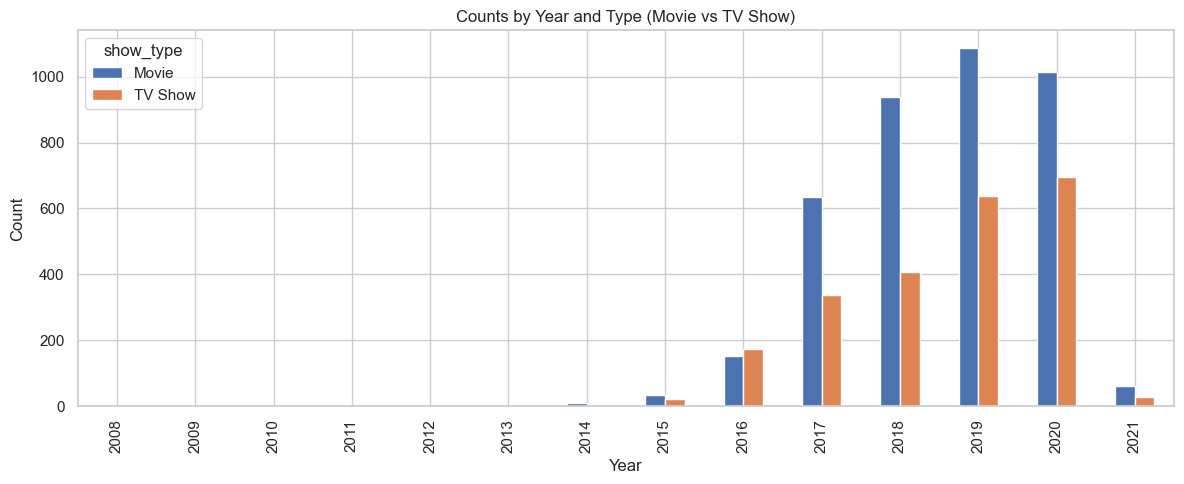

In [44]:
# Pivot and plot the trend (uses 'trend' DataFrame created above)
try:
    import matplotlib.pyplot as plt
    import numpy as np
except Exception:
    plt = None
if 'trend' not in globals() or trend is None or getattr(trend, 'empty', True):
    print('No trend data available — run the trend cell above first')
else:
    # safe pivot: ensure columns exist
    if 'year' not in trend.columns or 'show_type' not in trend.columns or 'count' not in trend.columns:
        print('Unexpected trend format; expected columns: year, show_type, count')
    else:
        pivot = trend.pivot(index='year', columns='show_type', values='count').fillna(0)
        if pivot.empty:
            print('Pivot resulted in empty data — nothing to plot')
        else:
            if plt is None:
                print('matplotlib not available; cannot plot')
            else:
                # Compute a readable cap: use the 98th percentile so a few large years don't compress the rest
                vals = pivot.values.flatten()
                max_val = int(vals.max()) if vals.size>0 else 0
                # ignore zeros for percentile if possible
                nonzero = vals[vals>0] if vals.size>0 else vals
                if nonzero.size>0:
                    cap = float(np.percentile(nonzero, 98)) * 1.1
                else:
                    cap = max_val
                ax = pivot.plot(kind='bar', stacked=False, figsize=(12,5))
                ax.set_title('Counts by Year and Type (Movie vs TV Show)')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                if max_val > 0 and max_val > cap * 1.05:
                    # Inform about the real maximum and cap the y-axis for readability
                    print(f'Note: maximum count = {max_val}. Y-axis capped at {int(cap)} (98th percentile) for readability.')
                    ax.set_ylim(0, cap)
                plt.tight_layout()

## Analysis 2 — Genre analysis
Top genres and how they change over time (primary genre = first listed). The top 8 genres overall and show their counts by year.

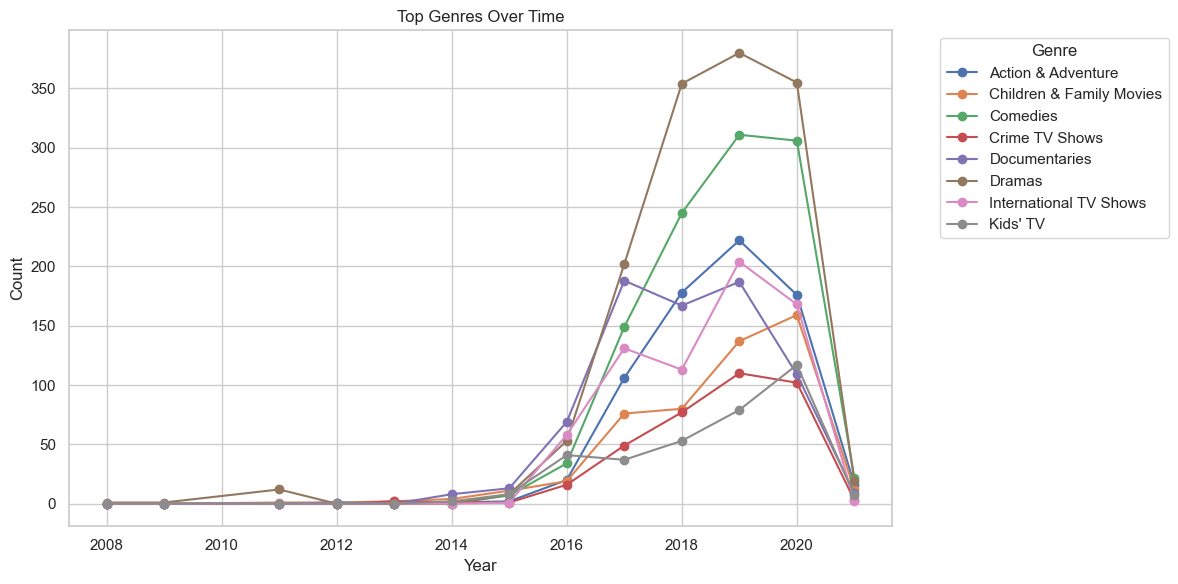

In [ ]:
# Top genres over time (safe, robust)
import matplotlib.pyplot as plt

if 'primary_genre' not in df2.columns:
    print('No primary_genre column found — run the genre extraction cell first')
else:
    df2['year'] = pd.to_numeric(df2['year'], errors='coerce').astype('Int64')
    top_genres = df2['primary_genre'].dropna().value_counts().nlargest(8).index.tolist()
    if not top_genres:
        print('No genres found in primary_genre')
    else:
        genre_trend = (df2[df2['primary_genre'].isin(top_genres)]
                       .dropna(subset=['year'])
                       .groupby(['year','primary_genre'])
                       .size()
                       .reset_index(name='count')
        )
        if genre_trend.empty:
            print('No year/genre counts to plot')
        else:
            genre_pivot = genre_trend.pivot(index='year', columns='primary_genre', values='count').fillna(0)
            if plt is None:
                print('matplotlib not available; cannot plot genre trends')
            else:
                ax = genre_pivot.plot(kind='line', figsize=(12,6), marker='o')
                ax.set_title('Top Genres Over Time')
                ax.set_xlabel('Year')
                ax.set_ylabel('Count')
                ax.legend(title='Genre', bbox_to_anchor=(1.05,1), loc='upper left')
                plt.tight_layout()

## Analysis 3 — Country-wise contributions
The top 10 countries by counts and show a bar plot.

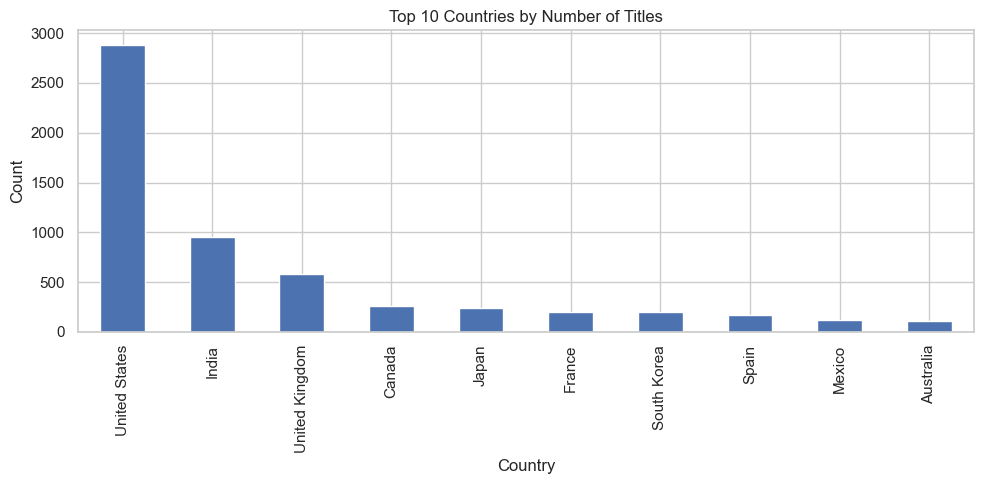

In [56]:
# Extract primary country (first listed) if present
country_col = None
for c in df2.columns:
    if c.lower()=='country' or 'country' in c.lower():
        country_col = c
        break

if country_col is not None:
    # take first listed country, strip whitespace
    primary = df2[country_col].astype(str).str.split(',').str[0].str.strip()
    # Convert empty strings and literal 'nan' (any case) to real missing values
    primary = primary.replace(r'^\s*$', pd.NA, regex=True)
    primary = primary.replace(r'(?i)^nan$', pd.NA, regex=True)
    df2['primary_country'] = primary
else:
    df2['primary_country'] = pd.NA

# count only non-missing countries so 'nan' doesn't appear as a category
top_countries = df2['primary_country'].dropna().value_counts().nlargest(10)
top_countries.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Country')
plt.ylabel('Count')
plt.tight_layout()

## Summary & Recommendations
Concise takeaways based on the plots and suggest strategic directions (e.g., invest in growing genres, balance Movies vs TV Shows by market).

In [48]:
# Short textual summary (example template)
summary = []
summary.append('Dataset contains {} rows and {} columns.'.format(df.shape[0], df.shape[1]))
if 'year' in df2.columns:
    yrs = df2['year'].dropna().astype(int)
    summary.append('Year range: {} - {}'.format(yrs.min(), yrs.max()))
summary.append('Top genres: ' + ', '.join(top_genres))
summary.append('Top countries: ' + ', '.join(top_countries.index.astype(str).tolist()))

for s in summary:
    print('-', s)

- Dataset contains 7789 rows and 11 columns.
- Top genres: Dramas, Comedies, Documentaries, Action & Adventure, International TV Shows, Children & Family Movies, Crime TV Shows, Kids' TV
- Top countries: United States, India, United Kingdom, nan, Canada, Japan, France, South Korea, Spain, Mexico
